## Import Libraries

In [20]:
import cv2
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd 
import sys
import pickle
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from deepface import DeepFace

## List Classes

In [21]:
IMG_SIZE = (160, 160)

dataset_path = Path('Faces')

In [22]:
names  = sorted([p.name for p in dataset_path.iterdir() if p.is_dir()])
labels = list(range(1, len(names) + 1))

name_to_label = dict(zip(names, labels))
label_to_name = {v: k for k, v in name_to_label.items()}

print(f"Classes ({len(names)}): {names}")

Classes (25): ['Akshay Kumar', 'Alexandra Daddario', 'Amitabh Bachchan', 'Andy Samberg', 'Billie Eilish', 'Brad Pitt', 'Camila Cabello', 'Charlize Theron', 'Claire Holt', 'Courtney Cox', 'Dwayne Johnson', 'Elizabeth Olsen', 'Ellen Degeneres', 'Henry Cavill', 'Hrithik Roshan', 'Lisa Kudrow', 'Margot Robbie', 'Natalie Portman', 'Priyanka Chopra', 'Robert Downey Jr', 'Roger Federer', 'Tom Cruise', 'Vijay Deverakonda', 'Virat Kohli', 'Zac Efron']


In [23]:
def preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    denoised = cv2.bilateralFilter(enhanced, 5, 50, 50)

    return denoised

Class: Ellen Degeneres
Image: Ellen Degeneres_23.jpg
ORIGINAL


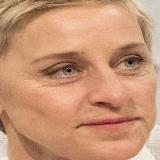

GRAY


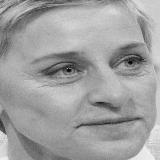

CLAHE


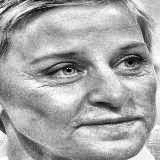

DENOISED


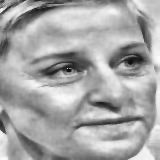

In [24]:
from PIL import Image
from IPython.display import display
import cv2
import os
import random

all_classes = [c for c in os.listdir(dataset_path)
               if (dataset_path / c).is_dir()]

random_class = random.choice(all_classes)
folder = dataset_path / random_class

images = [img for img in os.listdir(folder)
          if img.lower().endswith(('.jpg','.png','.jpeg'))]

img_name = random.choice(images)
img_path = folder / img_name

img = cv2.imread(str(img_path))

print("Class:", random_class)
print("Image:", img_name)

print("ORIGINAL")
display(Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))

print("GRAY")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
display(Image.fromarray(gray))

print("CLAHE")
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)
display(Image.fromarray(enhanced))

print("DENOISED")
denoised = cv2.bilateralFilter(enhanced, 5, 50, 50)
display(Image.fromarray(denoised))


In [25]:
def detect_face(image):
    face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    faces = face_cascade.detectMultiScale(image, 1.1, 5)

    if len(faces) == 0:
        return None

    x, y, w, h = max(faces, key=lambda b: b[2]*b[3])
    return (x, y, w, h)

In [26]:
def extract_face(image):
    # image is expected to be BGR (from cv2.imread)
    processed = preprocess(image)

    face_coords = detect_face(processed)

    if face_coords is None:
        # No face detected — use the full image instead of skipping
        # This keeps all samples in the dataset
        face = processed
    else:
        x, y, w, h = face_coords
        face = processed[y:y+h, x:x+w]

    face = cv2.resize(face, IMG_SIZE)
    return face


Class: Andy Samberg
Image: Andy Samberg_30.jpg
Face detected

STEP 1: ORIGINAL


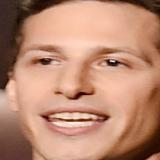


STEP 2: PREPROCESS


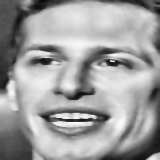


STEP 3: FACE DETECTION


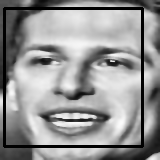


STEP 4: EXTRACT FACE


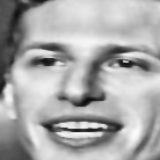


STEP 5: FINAL (160x160)


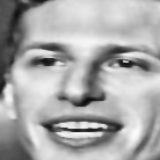

In [27]:
import cv2
import random
from IPython.display import display
from PIL import Image

all_classes = [c for c in os.listdir(dataset_path)
               if (dataset_path / c).is_dir()]

found = False

while not found:
    random_class = random.choice(all_classes)
    folder = dataset_path / random_class

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(('.jpg','.png','.jpeg'))]

    img_name = random.choice(images)
    img_path = folder / img_name

    image = cv2.imread(str(img_path))

    if image is None:
        continue

    processed = preprocess(image)
    coords = detect_face(processed)

    if coords is not None:
        found = True

print("Class:", random_class)
print("Image:", img_name)
print("Face detected")


print("\nSTEP 1: ORIGINAL")
display(Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)))


print("\nSTEP 2: PREPROCESS")

processed = preprocess(image)
display(Image.fromarray(processed))


print("\nSTEP 3: FACE DETECTION")

x, y, w, h = coords
img_box = processed.copy()

cv2.rectangle(img_box, (x, y), (x+w, y+h), (0, 255, 0), 2)

display(Image.fromarray(cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)))


print("\nSTEP 4: EXTRACT FACE")

face = extract_face(image)   
display(Image.fromarray(face))

print("\nSTEP 5: FINAL (160x160)")

final = cv2.resize(face, IMG_SIZE)
display(Image.fromarray(final))

In [28]:
import os
import cv2

total = 0
detected = 0

all_classes = [c for c in os.listdir(dataset_path)
               if (dataset_path / c).is_dir()]

for person_name in all_classes:
    folder = dataset_path / person_name

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

    for img_name in images:

        img_path = folder / img_name
        image = cv2.imread(str(img_path))

        if image is None:
            continue

        total += 1

        # USE YOUR FUNCTIONS ONLY
        processed = preprocess(image)
        coords = detect_face(processed)

        if coords is not None:
            detected += 1



# RESULTS
print("\n")
print("TOTAL IMAGES:", total)
print("DETECTED FACES:", detected)
print("DETECTION RATE:", round(detected / total, 2) if total > 0 else 0)




TOTAL IMAGES: 1225
DETECTED FACES: 273
DETECTION RATE: 0.22


In [29]:
def get_embedding(face_img):
    try:
        face_img = cv2.cvtColor(face_img, cv2.COLOR_GRAY2RGB)

        result = DeepFace.represent(
            face_img,
            model_name="ArcFace",
            enforce_detection=False
        )

        return result[0]["embedding"]

    except:
        return None

In [30]:
import cv2
import os
import numpy as np
from pathlib import Path
from deepface import DeepFace
import pickle

X, y = [], []

for person_name in os.listdir(dataset_path):
    folder = dataset_path / person_name

    if not folder.is_dir():
        continue

    for img_name in os.listdir(folder):
        img_path = folder / img_name

        image = cv2.imread(str(img_path))
        if image is None:
            continue

        # FIX: removed wrong cvtColor(BGR2RGB) — cv2.imread returns BGR,
        # preprocess expects BGR (it does BGR2GRAY internally)
        face = extract_face(image)

        if face is None:
            continue

        embedding = get_embedding(face)

        if embedding is None:
            continue

        X.append(embedding)
        y.append(person_name)

X = np.array(X)
y = np.array(y)

print("Final dataset size:", X.shape)
print("Number of classes:", len(set(y)))
print("PIPELINE READY ")

with open("embeddings.pkl", "wb") as f:
    pickle.dump({"X": X, "y": y}, f)

print("Embeddings saved to embeddings.pkl")


Final dataset size: (1225, 512)
Number of classes: 25
PIPELINE READY 
Embeddings saved to embeddings.pkl


In [34]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC

file_path = "embeddings.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]


# split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# then LDA
lda = LDA()
X_train = lda.fit_transform(X_train, y_train)
X_test = lda.transform(X_test)

In [35]:
# SVM
svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [36]:
from sklearn.metrics import accuracy_score

y_train_pred = svm_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [37]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9591836734693877
                    precision    recall  f1-score   support

      Akshay Kumar       1.00      0.89      0.94         9
Alexandra Daddario       1.00      0.90      0.95        10
  Amitabh Bachchan       1.00      1.00      1.00        10
      Andy Samberg       0.91      1.00      0.95        10
     Billie Eilish       0.91      1.00      0.95        10
         Brad Pitt       1.00      0.90      0.95        10
    Camila Cabello       1.00      0.90      0.95        10
   Charlize Theron       1.00      0.80      0.89        10
       Claire Holt       0.75      1.00      0.86         9
      Courtney Cox       1.00      1.00      1.00        10
    Dwayne Johnson       1.00      1.00      1.00        10
   Elizabeth Olsen       1.00      1.00      1.00         9
   Ellen Degeneres       1.00      1.00      1.00        10
      Henry Cavill       1.00      1.00      1.00        10
    Hrithik Roshan       0.91      1.00      0.95        10
       Lis

In [38]:
import numpy as np
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# LOAD DATA
file_path = "embeddings.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

X = np.array(data["X"])
y = np.array(data["y"])

# CROSS VALIDATION
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_accs = []
test_accs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    print(f"\n Fold {fold+1} ")

    # split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    # LDA (inside fold)
    lda = LDA()
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda = lda.transform(X_test)

    # SVM
    svm_model = SVC(kernel="linear", probability=True)
    svm_model.fit(X_train_lda, y_train)

    # TRAIN ACCURACY
    y_train_pred = svm_model.predict(X_train_lda)
    train_acc = accuracy_score(y_train, y_train_pred)

    # TEST ACCURACY
    y_test_pred = svm_model.predict(X_test_lda)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

# FINAL RESULT
print("Mean Train Accuracy:", np.mean(train_accs))
print("Mean Test Accuracy:", np.mean(test_accs))
print("Std Test Accuracy:", np.std(test_accs))



 Fold 1 
Train Accuracy: 1.0
Test Accuracy: 0.9428571428571428

 Fold 2 
Train Accuracy: 1.0
Test Accuracy: 0.9346938775510204

 Fold 3 
Train Accuracy: 1.0
Test Accuracy: 0.9224489795918367

 Fold 4 
Train Accuracy: 1.0
Test Accuracy: 0.9224489795918367

 Fold 5 
Train Accuracy: 1.0
Test Accuracy: 0.9469387755102041
Mean Train Accuracy: 1.0
Mean Test Accuracy: 0.9338775510204081
Std Test Accuracy: 0.010130345833461946


In [40]:
# FIX: Train final model on ALL data after cross-validation
# The CV loop above was only for evaluation — now we train on everything
# so the attendance system has a proper model

print("\nTraining final model on all data...")

lda = LDA()
X_lda_full = lda.fit_transform(X, y)

svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_lda_full, y)

print("Final model trained on all", len(y), "samples ")

# Save model for reuse
with open("model.pkl", "wb") as f:
    pickle.dump({"lda": lda, "svm": svm_model}, f)

print("Model saved to model.pkl ")



Training final model on all data...
Final model trained on all 1225 samples 
Model saved to model.pkl 
